In [1]:
import pandas as pd

# Load new files
pre  = pd.read_csv("/content/Pre-Assessment AI tutor (Responses) - Form Responses 1.csv")
post = pd.read_csv("/content/AI Tutor Experience Feedback  (Responses) - Form Responses 1.csv")

# Standardize column names
pre.columns  = pre.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+","_", regex=True)
post.columns = post.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+","_", regex=True)

print("Pre columns:", pre.columns.tolist())
print("Post columns:", post.columns.tolist())


Pre columns: ['timestamp', 'by_continuing_i_confirm_i_have_read_the_study_information_participation_is_voluntary_i_may_stop_anytime_my_responses_will_be_used_for_research_and_reported_in_aggregate_with_no_personal_identifiers_shared', 'email_address', 'what_best_describes_your_current_role_', 'how_familiar_are_you_with_using_ai_based_educational_tools_', 'how_often_do_you_use_textbooks_for_learning_', 'have_you_used_any_interactive_or_digital_learning_platforms_before_', 'please_list_any_digital_learning_platforms_you_ve_used', 'which_learning_methods_do_you_prefer_', 'what_are_your_main_learning_goals_with_the_ai_tutor_e_g_improve_recall_exam_prep_apply_knowledge_to_work_explore_ai_tools_', 'what_do_you_expect_from_an_ai_powered_educational_tool_', 'how_comfortable_are_you_with_using_tools_like_google_colab_or_jupyter_notebooks_', 'have_you_used_any_ai_driven_tools_e_g_chatbots_recommendation_systems_etc_before_', 'please_describe_your_experience_with_ai_tools', 'what_kind_of_content_

In [2]:
import pandas as pd

# Load new files
# Load new files
pre  = pd.read_csv("/content/Pre-Assessment AI tutor (Responses) - Form Responses 1.csv")
post = pd.read_csv("/content/AI Tutor Experience Feedback  (Responses) - Form Responses 1.csv")
# Standardize column names
pre.columns  = pre.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+","_", regex=True)
post.columns = post.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+","_", regex=True)

print("Pre columns:", pre.columns.tolist())
print("Post columns:", post.columns.tolist())


Pre columns: ['timestamp', 'by_continuing_i_confirm_i_have_read_the_study_information_participation_is_voluntary_i_may_stop_anytime_my_responses_will_be_used_for_research_and_reported_in_aggregate_with_no_personal_identifiers_shared', 'email_address', 'what_best_describes_your_current_role_', 'how_familiar_are_you_with_using_ai_based_educational_tools_', 'how_often_do_you_use_textbooks_for_learning_', 'have_you_used_any_interactive_or_digital_learning_platforms_before_', 'please_list_any_digital_learning_platforms_you_ve_used', 'which_learning_methods_do_you_prefer_', 'what_are_your_main_learning_goals_with_the_ai_tutor_e_g_improve_recall_exam_prep_apply_knowledge_to_work_explore_ai_tools_', 'what_do_you_expect_from_an_ai_powered_educational_tool_', 'how_comfortable_are_you_with_using_tools_like_google_colab_or_jupyter_notebooks_', 'have_you_used_any_ai_driven_tools_e_g_chatbots_recommendation_systems_etc_before_', 'please_describe_your_experience_with_ai_tools', 'what_kind_of_content_

In [3]:
import pandas as pd

# Load updated files
# Load new files
pre  = pd.read_csv("/content/Pre-Assessment AI tutor (Responses) - Form Responses 1.csv")
post = pd.read_csv("/content/AI Tutor Experience Feedback  (Responses) - Form Responses 1.csv")

# Standardize column names
pre.columns  = pre.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+","_", regex=True)
post.columns = post.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+","_", regex=True)

# PRE: Drop timestamp and consent column
pre = pre.drop(columns=[
    "timestamp",
    "by_continuing_i_confirm_i_have_read_the_study_information_participation_is_voluntary_i_may_stop_anytime_my_responses_will_be_used_for_research_and_reported_in_aggregate_with_no_personal_identifiers_shared"
], errors="ignore")

#  POST: Drop the first 3 columns (timestamp, email_address, full_name)
post = post.drop(columns=["timestamp", "email_address", "full_name"], errors="ignore")

#  Rename email_address_1 → email_address for consistency
if "email_address_1" in post.columns:
    post = post.rename(columns={"email_address_1": "email_address"})

#  Drop duplicate columns (just in case)
post = post.loc[:, ~post.columns.duplicated()]

#  Remove duplicates
pre  = pre.drop_duplicates()
post = post.drop_duplicates()

# Drop rows with missing email
pre  = pre[pre["email_address"].notna()]
post = post[post["email_address"].notna()]

#  Final counts
print(" Cleaned pre-assessment responses:", pre.shape[0])
print(" Cleaned post-assessment responses:", post.shape[0])


 Cleaned pre-assessment responses: 60
 Cleaned post-assessment responses: 60


In [4]:
# For pre: drop duplicates by email_address, keeping the last submission
pre = pre.sort_index().drop_duplicates(subset=["email_address"], keep="last")

# For post: drop duplicates by email_address, keeping the last submission
post = post.sort_index().drop_duplicates(subset=["email_address"], keep="last")

print("Unique pre emails:", pre["email_address"].nunique())
print(" Unique post emails:", post["email_address"].nunique())
print(" Pre dataset size:", pre.shape[0])
print(" Post dataset size:", post.shape[0])


Unique pre emails: 60
 Unique post emails: 58
 Pre dataset size: 60
 Post dataset size: 58


In [5]:
# Clean email formatting in both pre and post
pre["email_address"] = (
    pre["email_address"].astype(str).str.strip().str.lower().str.replace(r"\s+", "", regex=True)
)
post["email_address"] = (
    post["email_address"].astype(str).str.strip().str.lower().str.replace(r"\s+", "", regex=True)
)

# Drop duplicates again after cleaning
pre = pre.drop_duplicates(subset=["email_address"])
post = post.drop_duplicates(subset=["email_address"])

# Now find common emails
common_emails = set(pre["email_address"]).intersection(set(post["email_address"]))
print(" Participants who did BOTH (after cleaning):", len(common_emails))

# Filter matched datasets
pre_matched = pre[pre["email_address"].isin(common_emails)].reset_index(drop=True)
post_matched = post[post["email_address"].isin(common_emails)].reset_index(drop=True)

print(" Matched pre responses:", pre_matched.shape[0])
print("Matched post responses:", post_matched.shape[0])


 Participants who did BOTH (after cleaning): 57
 Matched pre responses: 57
Matched post responses: 57


In [6]:
# Step 1: Define sets
pre_emails  = set(pre["email_address"])
post_emails = set(post["email_address"])

only_in_pre  = pre_emails - post_emails
only_in_post = post_emails - pre_emails
common       = pre_emails & post_emails

# Step 2: Print summary
print(" In BOTH:", len(common))
print(" Only in PRE:", len(only_in_pre))
print(" Only in POST:", len(only_in_post))

# Step 3: List them
print("\n--- Emails ONLY in PRE ---")
for e in sorted(list(only_in_pre)):
    print(e)

print("\n--- Emails ONLY in POST ---")
for e in sorted(list(only_in_post)):
    print(e)


 In BOTH: 57
 Only in PRE: 3
 Only in POST: 1

--- Emails ONLY in PRE ---
fmoradi@clemson.edu
mshujaa@clemson.edu
sheelask@bgsit.ac.in

--- Emails ONLY in POST ---
shafinaz@gmail.com


In [7]:
# assume `pre` and `post` are already loaded + emails normalized
pre_emails  = set(pre["email_address"])
post_emails = set(post["email_address"])
common_emails = pre_emails & post_emails

# filter to matched only
pre_matched  = pre[pre["email_address"].isin(common_emails)].reset_index(drop=True)
post_matched = post[post["email_address"].isin(common_emails)].reset_index(drop=True)

print(" Matched pre rows:", pre_matched.shape[0])
print(" Matched post rows:", post_matched.shape[0])

# save
pre_matched.to_csv("/content/clean_pre_matched.csv", index=False)
post_matched.to_csv("/content/clean_post_matched.csv", index=False)


 Matched pre rows: 57
 Matched post rows: 57


In [8]:
merged = pd.merge(pre_matched, post_matched, on="email_address", suffixes=("_pre","_post"))
print(" Merged shape:", merged.shape)
merged.to_csv("/content/merged_pre_post.csv", index=False)


 Merged shape: (57, 31)


**step 1 — make numeric columns for the post survey (Likert mappings)**

In [9]:
# --- STEP 1: Numeric encodings for post survey ---

import numpy as np
import pandas as pd

# Copy to avoid accidental chained assignments later
post_num = post.copy()

# Helpers: pull a single digit from strings like "5", or "5 (Excellent)"
def _to_1_5(x):
    if pd.isna(x): return np.nan
    s = str(x)
    m = pd.Series(s).str.extract(r'(\d)').iloc[0,0]
    return float(m) if m in list('12345') else np.nan

# Map 1–5 items
likert_cols = [
    "how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent_",
    "how_easy_was_it_to_use_the_ai_tutor_interface_1_very_difficult_5_very_easy_",
    "how_helpful_were_the_guided_walkthroughs_in_getting_started_1_not_helpful_5_very_helpful_",
    "how_engaging_did_you_find_the_different_learning_modes_business_case_storytelling_challenges_1_not_engaging_5_very_engaging_",
    "how_would_you_rate_the_quality_and_clarity_of_the_content_presented_in_the_ai_tutor_1_very_poor_5_excellent_",
    "overall_how_easy_was_it_to_complete_your_learning_session_with_the_ai_tutor_1_very_difficult_5_very_easy_"
]

for c in likert_cols:
    if c in post_num.columns:
        post_num[c + "_num"] = post_num[c].apply(_to_1_5)

# Map Yes/No/Maybe to numbers
yn_map = {"Yes": 1.0, "No": 0.0, "Maybe": 0.5, "maybe": 0.5}
if "was_the_feedback_xp_correct_incorrect_answers_progress_tracking_helpful_in_understanding_your_performance_" in post_num.columns:
    post_num["feedback_helpful_num"] = post_num["was_the_feedback_xp_correct_incorrect_answers_progress_tracking_helpful_in_understanding_your_performance_"].map(yn_map)

# Understanding -> 1..5
improve_map = {
    "Yes, significantly": 5.0,
    "Yes, somewhat": 4.0,
    "Neutral": 3.0,
    "No, not really": 2.0,
    "No": 1.0
}
if "did_the_ai_tutor_help_improve_your_understanding_of_the_concepts_" in post_num.columns:
    post_num["understanding_num"] = post_num["did_the_ai_tutor_help_improve_your_understanding_of_the_concepts_"].map(improve_map)

# Speed -> 1..5
speed_map = {
    "Fast and smooth": 5.0,
    "Acceptable": 4.0,
    "A bit slow": 3.0,
    "Very slow or laggy": 2.0,
    "Didn’t work properly": 1.0,
    "Didn't work properly": 1.0
}
speed_col = "how_would_you_describe_the_speed_and_performance_of_the_ai_tutor_in_google_colab_"
if speed_col in post_num.columns:
    post_num["speed_num"] = post_num[speed_col].map(speed_map)

# Quick sanity check
post_num_filter = post_num[[c+"_num" for c in likert_cols if c in post_num.columns] +
                           [c for c in ["feedback_helpful_num","understanding_num","speed_num"] if c in post_num.columns]]
post_num_filter.describe()


,how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent__num,how_easy_was_it_to_use_the_ai_tutor_interface_1_very_difficult_5_very_easy__num,how_helpful_were_the_guided_walkthroughs_in_getting_started_1_not_helpful_5_very_helpful__num,how_engaging_did_you_find_the_different_learning_modes_business_case_storytelling_challenges_1_not_engaging_5_very_engaging__num,how_would_you_rate_the_quality_and_clarity_of_the_content_presented_in_the_ai_tutor_1_very_poor_5_excellent__num,overall_how_easy_was_it_to_complete_your_learning_session_with_the_ai_tutor_1_very_difficult_5_very_easy__num,feedback_helpful_num,understanding_num,speed_num
count,57.000000,57.000000,57.000000,57.000000,58.000000,58.000000,57.000000,58.000000,57.000000
mean,4.701754,4.596491,4.701754,4.701754,4.758621,4.775862,0.964912,4.706897,4.561404
std,0.822993,0.942255,0.822993,0.498745,0.470548,0.460477,0.159789,0.495900,0.681845
min,1.000000,1.000000,1.000000,3.000000,3.000000,3.000000,0.000000,3.000000,3.000000
25%,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,1.000000,4.000000,4.000000
50%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,5.000000,5.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,5.000000,5.000000


**Step 2: KMO & Bartlett**

In [10]:
# STEP 2: KMO & Bartlett prechecks for EFA

# If you followed my earlier steps you may have `post_num`.
# If not, this will fall back to `post`.
df = globals().get("post_num", post).copy()

# six core 1–5 perception items to use in EFA
efa_cols = [
    "how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent__num",
    "how_easy_was_it_to_use_the_ai_tutor_interface_1_very_difficult_5_very_easy__num",
    "how_helpful_were_the_guided_walkthroughs_in_getting_started_1_not_helpful_5_very_helpful__num",
    "how_engaging_did_you_find_the_different_learning_modes_business_case_storytelling_challenges_1_not_engaging_5_very_engaging__num",
    "how_would_you_rate_the_quality_and_clarity_of_the_content_presented_in_the_ai_tutor_1_very_poor_5_excellent__num",
    "overall_how_easy_was_it_to_complete_your_learning_session_with_the_ai_tutor_1_very_difficult_5_very_easy__num",
]

# keep only available columns and drop rows with any missing among them
efa_items = [c for c in efa_cols if c in df.columns]
efa_df = df[efa_items].dropna().astype(float)

print("EFA matrix shape:", efa_df.shape)

# install + compute KMO and Bartlett
!pip -q install factor-analyzer
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

kmo_all, kmo_model = calculate_kmo(efa_df)
bart_chi2, bart_p = calculate_bartlett_sphericity(efa_df)

print(f"KMO overall: {kmo_model:.3f}  (≥ .60 is acceptable, ≥ .70 good)")
print(f"Bartlett’s test: chi2={bart_chi2:.2f}, p={bart_p:.4g}  (p<.05 suggests factorability)")


EFA matrix shape: (57, 6)
KMO overall: 0.674  (≥ .60 is acceptable, ≥ .70 good)
Bartlett’s test: chi2=114.66, p=2.044e-17  (p<.05 suggests factorability)


In [11]:
# Inspect missingness for the 6 key items
efa_cols = [
    "how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent__num",
    "how_easy_was_it_to_use_the_ai_tutor_interface_1_very_difficult_5_very_easy__num",
    "how_helpful_were_the_guided_walkthroughs_in_getting_started_1_not_helpful_5_very_helpful__num",
    "how_engaging_did_you_find_the_different_learning_modes_business_case_storytelling_challenges_1_not_engaging_5_very_engaging__num",
    "how_would_you_rate_the_quality_and_clarity_of_the_content_presented_in_the_ai_tutor_1_very_poor_5_excellent__num",
    "overall_how_easy_was_it_to_complete_your_learning_session_with_the_ai_tutor_1_very_difficult_5_very_easy__num",
]

missing_report = post_num[efa_cols].isna().sum()
print("Missing values per column:")
print(missing_report)


Missing values per column:
how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent__num                                           1
how_easy_was_it_to_use_the_ai_tutor_interface_1_very_difficult_5_very_easy__num                                                     1
how_helpful_were_the_guided_walkthroughs_in_getting_started_1_not_helpful_5_very_helpful__num                                       1
how_engaging_did_you_find_the_different_learning_modes_business_case_storytelling_challenges_1_not_engaging_5_very_engaging__num    1
how_would_you_rate_the_quality_and_clarity_of_the_content_presented_in_the_ai_tutor_1_very_poor_5_excellent__num                    0
overall_how_easy_was_it_to_complete_your_learning_session_with_the_ai_tutor_1_very_difficult_5_very_easy__num                       0
dtype: int64


**Step 3 – Parallel Analysis (to decide number of factors)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


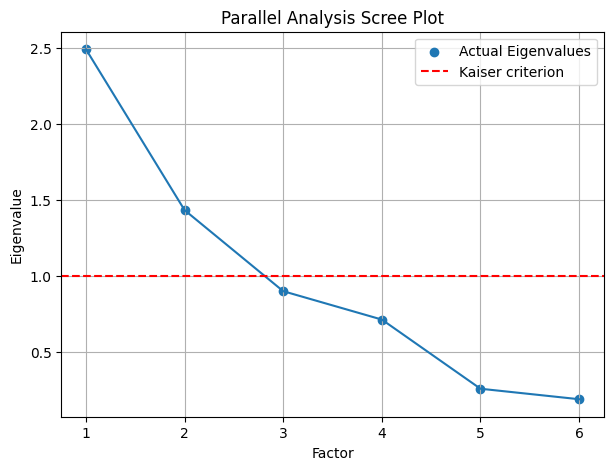

In [12]:
!pip install --quiet factor-analyzer

import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo, FactorAnalyzer

# Step 4: Parallel Analysis - to determine number of factors
fa = FactorAnalyzer(rotation=None)
fa.fit(efa_df)

# Get eigenvalues and scree plot
ev, v = fa.get_eigenvalues()

plt.figure(figsize=(7, 5))
plt.scatter(range(1, efa_df.shape[1]+1), ev, label="Actual Eigenvalues")
plt.plot(range(1, efa_df.shape[1]+1), ev)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser criterion')
plt.title("Parallel Analysis Scree Plot")
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(True)
plt.show()


**Step 4 – Extract and Rotate the Factors**

In [13]:
from factor_analyzer import FactorAnalyzer

# Step 5: Run factor analysis with 2 factors and varimax rotation
fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(efa_df)

# Get loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=efa_df.columns,
    columns=["Factor 1", "Factor 2"]
)
print("Factor Loadings:")
print(loadings.round(3))

# Optional: Variance explained
variance = fa.get_factor_variance()
print("\nVariance explained:")
print(f"  Factor 1: {variance[1][0]*100:.2f}%")
print(f"  Factor 2: {variance[1][1]*100:.2f}%")
print(f"  Total variance explained: {variance[1].sum()*100:.2f}%")


Factor Loadings:
                                                    Factor 1  Factor 2
how_would_you_rate_your_overall_experience_with...     0.885     0.026
how_easy_was_it_to_use_the_ai_tutor_interface_1...     0.881     0.224
how_helpful_were_the_guided_walkthroughs_in_get...     0.833    -0.160
how_engaging_did_you_find_the_different_learnin...    -0.011     0.599
how_would_you_rate_the_quality_and_clarity_of_t...     0.076     0.512
overall_how_easy_was_it_to_complete_your_learni...    -0.009     0.246

Variance explained:
  Factor 1: 37.65%
  Factor 2: 12.62%
  Total variance explained: 50.27%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Step 6 – Visualize Factor Loadings**

/tmp/ipython-input-1527870438.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


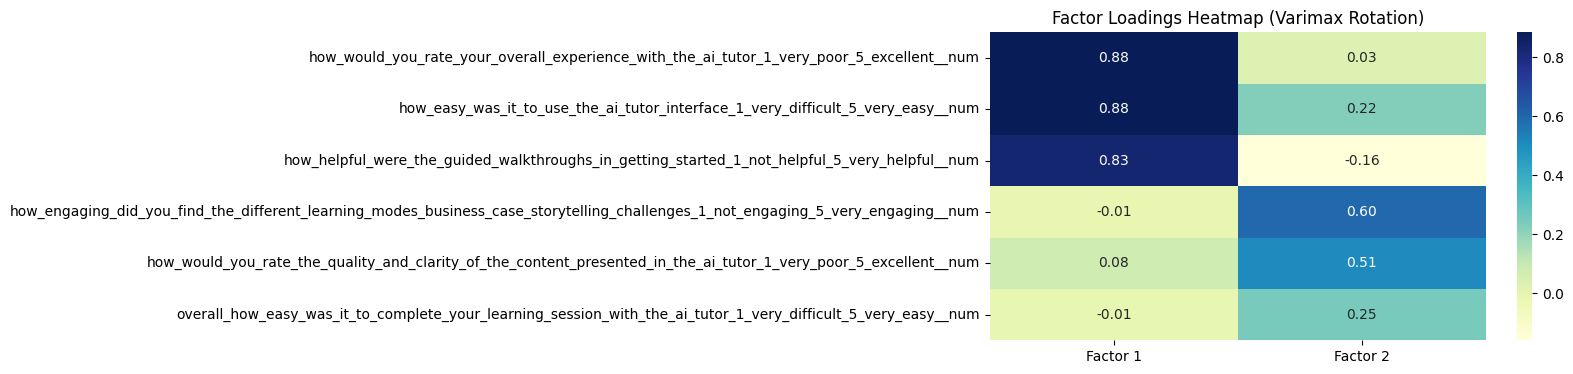

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.heatmap(loadings, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Factor Loadings Heatmap (Varimax Rotation)")
plt.tight_layout()
plt.show()


**Step 7 – Reliability Analysis (Cronbach’s Alpha)**

In [15]:
from scipy.stats import pearsonr

# Factor 1 items (usability)
factor1_items = [
    "how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent__num",
    "how_easy_was_it_to_use_the_ai_tutor_interface_1_very_difficult_5_very_easy__num",
    "how_helpful_were_the_guided_walkthroughs_in_getting_started_1_not_helpful_5_very_helpful__num"
]

# Factor 2 items (engagement & content quality)
factor2_items = [
    "how_engaging_did_you_find_the_different_learning_modes_business_case_storytelling_challenges_1_not_engaging_5_very_engaging__num",
    "how_would_you_rate_the_quality_and_clarity_of_the_content_presented_in_the_ai_tutor_1_very_poor_5_excellent__num"
]

# Cronbach's alpha function
def cronbach_alpha(df):
    df_corr = df.corr()
    n = len(df_corr)
    mean_corr = df_corr.values[np.triu_indices(n, 1)].mean()
    return (n * mean_corr) / (1 + (n - 1) * mean_corr)

alpha_factor1 = cronbach_alpha(efa_df[factor1_items])
alpha_factor2 = cronbach_alpha(efa_df[factor2_items])

print("Cronbach’s α for Factor 1 (Usability):", round(alpha_factor1, 3))
print("Cronbach’s α for Factor 2 (Engagement):", round(alpha_factor2, 3))


Cronbach’s α for Factor 1 (Usability): 0.895
Cronbach’s α for Factor 2 (Engagement): 0.449


**Create a “Familiarity” baseline from the pre-assessment**

In [16]:
import numpy as np

# Copy matched pre dataset
pre_num = pre_matched.copy()

# Map familiarity levels to numeric scores
familiarity_map = {
    "not familiar at all": 1,
    "somewhat familiar": 2,
    "very familiar": 3
}
pre_num["familiarity_num"] = pre_num["how_familiar_are_you_with_using_ai_based_educational_tools_"].str.strip().str.lower().map(familiarity_map)

# Map comfort with Colab
comfort_map = {
    "not comfortable": 1,
    "somewhat comfortable": 2,
    "very comfortable": 3
}
pre_num["comfort_num"] = pre_num["how_comfortable_are_you_with_using_tools_like_google_colab_or_jupyter_notebooks_"].str.strip().str.lower().map(comfort_map)

# Binary: used AI tools before
pre_num["used_ai_num"] = pre_num["have_you_used_any_ai_driven_tools_e_g_chatbots_recommendation_systems_etc_before_"].str.strip().str.lower().map({
    "no": 0,
    "maybe": 0.5,
    "yes": 1
})

# Preview numeric pre metrics
pre_num[["email_address", "familiarity_num", "comfort_num", "used_ai_num"]].head()


,email_address,familiarity_num,comfort_num,used_ai_num
0,shuhaoz@clemson.edu,1,2,1.0
1,usiriko@clemson.edu,2,2,1.0
2,seerauttej25@gmail.com,3,3,0.5
3,juttugabalasai97@gmail.com,2,3,1.0
4,chinmaypatil307@gmail.com,3,1,0.0


In [17]:
# Finalize pre-score data (drop email)
pre_scores = pre_num[["familiarity_num", "comfort_num", "used_ai_num"]].copy()

# Basic stats
print("📊 Pre-assessment summary:")
print(pre_scores.describe().round(2))


📊 Pre-assessment summary:
       familiarity_num  comfort_num  used_ai_num
count            57.00        57.00        57.00
mean              2.40         2.39         0.84
std               0.53         0.67         0.34
min               1.00         1.00         0.00
25%               2.00         2.00         1.00
50%               2.00         2.00         1.00
75%               3.00         3.00         1.00
max               3.00         3.00         1.00


In [20]:
# Map understanding responses
understanding_map = {
    "no": 0,
    "no, not really": 0,
    "neutral": 0.5,
    "yes, somewhat": 0.75,
    "yes, significantly": 1
}

post_num["understanding_num"] = post_num[
    "did_the_ai_tutor_help_improve_your_understanding_of_the_concepts_"
].str.strip().str.lower().map(understanding_map)

# ✅ Correct full column name for overall experience
post_num["overall_experience_num"] = post_num[
    "how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent__num"
]

# Final numeric data (drop email)
post_scores = post_num[["understanding_num", "overall_experience_num"]].copy()

# Summary
print("📊 Post-assessment summary:")
print(post_scores.describe().round(2))


📊 Post-assessment summary:
       understanding_num  overall_experience_num
count              58.00                   57.00
mean                0.93                    4.70
std                 0.12                    0.82
min                 0.50                    1.00
25%                 0.75                    5.00
50%                 1.00                    5.00
75%                 1.00                    5.00
max                 1.00                    5.00


**Pre vs. Post Significance Testing (Paired)**

In [22]:
from scipy.stats import wilcoxon

# Align pre and post by index and drop missing pairs
paired_df = pd.concat([
    pre_scores["familiarity_num"].reset_index(drop=True),
    post_scores["understanding_num"].reset_index(drop=True) * 3  # scale 0–1 to 0–3
], axis=1).dropna()

paired_df.columns = ["familiarity_num", "understanding_num_scaled"]

# Run Wilcoxon signed-rank test (pre vs post)
stat, p_val = wilcoxon(paired_df["familiarity_num"], paired_df["understanding_num_scaled"])

print("📊 Wilcoxon Test – Pre familiarity vs Post understanding")
print(f"Statistic: {stat:.3f}, p-value: {p_val:.5f}")


📊 Wilcoxon Test – Pre familiarity vs Post understanding
Statistic: 81.000, p-value: 0.00002


**Wilcoxon Test: Comfort → Overall Experience**

In [23]:
# Align and scale post overall experience to 1–3 scale (since pre comfort is 1–3)
paired_df2 = pd.concat([
    pre_scores["comfort_num"].reset_index(drop=True),
    (post_scores["overall_experience_num"].reset_index(drop=True) / 5) * 3  # scale 1–5 to 1–3
], axis=1).dropna()

paired_df2.columns = ["comfort_num", "overall_experience_scaled"]

# Run Wilcoxon test
stat2, p_val2 = wilcoxon(paired_df2["comfort_num"], paired_df2["overall_experience_scaled"])

print("📊 Wilcoxon Test – Pre comfort vs Post overall experience")
print(f"Statistic: {stat2:.3f}, p-value: {p_val2:.5f}")


📊 Wilcoxon Test – Pre comfort vs Post overall experience
Statistic: 79.000, p-value: 0.00044


/tmp/ipython-input-2573238211.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df_melted, x="Measure", y="Score", palette="coolwarm")
/tmp/ipython-input-2573238211.py:25: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


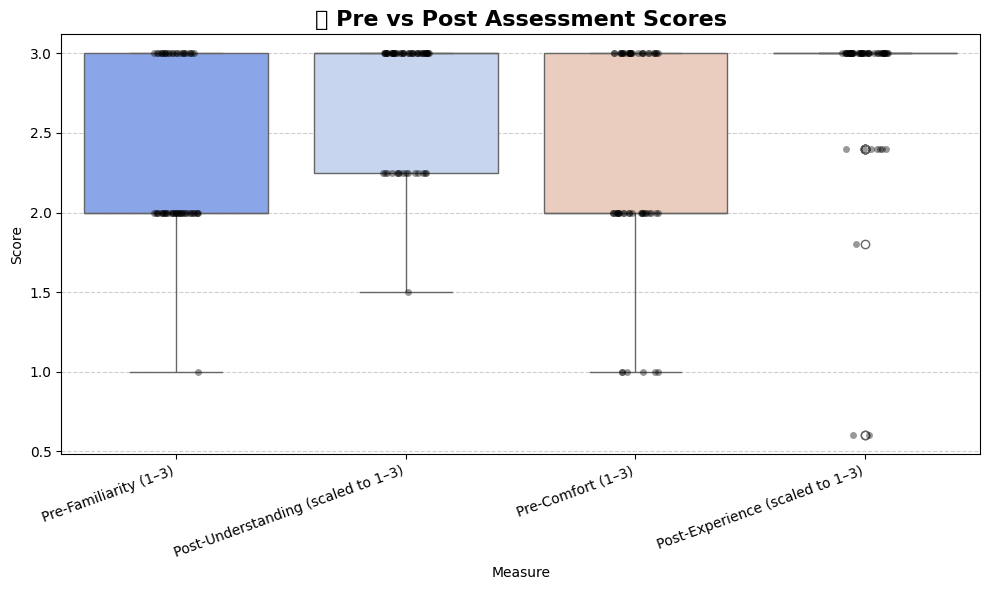

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare combined data for plotting
box_df = pd.DataFrame({
    "Pre-Familiarity (1–3)": pre_scores["familiarity_num"],
    "Post-Understanding (scaled to 1–3)": post_scores["understanding_num"].reset_index(drop=True) * 3,
    "Pre-Comfort (1–3)": pre_scores["comfort_num"],
    "Post-Experience (scaled to 1–3)": (post_scores["overall_experience_num"].reset_index(drop=True) / 5) * 3
})

# Melt for seaborn
box_df_melted = box_df.melt(var_name="Measure", value_name="Score")

# Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=box_df_melted, x="Measure", y="Score", palette="coolwarm")
sns.stripplot(data=box_df_melted, x="Measure", y="Score", color="black", alpha=0.4, jitter=True)

plt.title("📊 Pre vs Post Assessment Scores", fontsize=16, weight="bold")
plt.ylabel("Score")
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1573153747.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=box_df_melted, x="Measure", y="Score", palette="coolwarm")
/tmp/ipython-input-1573153747.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


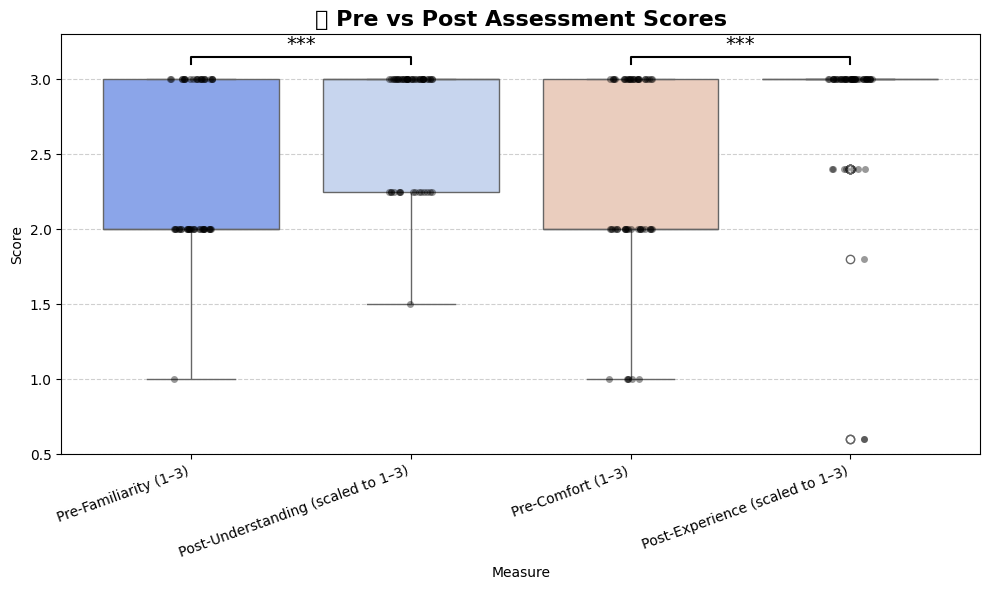

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data again
box_df = pd.DataFrame({
    "Pre-Familiarity (1–3)": pre_scores["familiarity_num"],
    "Post-Understanding (scaled to 1–3)": post_scores["understanding_num"].reset_index(drop=True) * 3,
    "Pre-Comfort (1–3)": pre_scores["comfort_num"],
    "Post-Experience (scaled to 1–3)": (post_scores["overall_experience_num"].reset_index(drop=True) / 5) * 3
})

box_df_melted = box_df.melt(var_name="Measure", value_name="Score")

# Plot
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=box_df_melted, x="Measure", y="Score", palette="coolwarm")
sns.stripplot(data=box_df_melted, x="Measure", y="Score", color="black", alpha=0.4, jitter=True)

plt.title("📊 Pre vs Post Assessment Scores", fontsize=16, weight="bold")
plt.ylabel("Score")
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle="--", alpha=0.6)

# Add significance annotations
# positions correspond to x-axis categories (0-3)
pairs = [(0,1), (2,3)]
p_values = [0.00002, 0.00044]
for (x1, x2), p in zip(pairs, p_values):
    y = 3.1  # vertical position
    plt.plot([x1, x1, x2, x2], [y, y+0.05, y+0.05, y], lw=1.5, c='k')
    significance = "***" if p < 0.001 else "**" if p < 0.01 else "*"
    plt.text((x1 + x2) * 0.5, y + 0.07, significance, ha='center', va='bottom', fontsize=14)

plt.ylim(0.5, 3.3)
plt.tight_layout()
plt.show()


**Build a paired dataset and create groups**

In [28]:
print(post_m.columns.tolist())


['email_address', 'what_best_describes_your_current_role_', 'how_did_you_access_the_ai_tutor_', 'how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent_', 'how_easy_was_it_to_use_the_ai_tutor_interface_1_very_difficult_5_very_easy_', 'how_helpful_were_the_guided_walkthroughs_in_getting_started_1_not_helpful_5_very_helpful_', 'how_engaging_did_you_find_the_different_learning_modes_business_case_storytelling_challenges_1_not_engaging_5_very_engaging_', 'which_challenge_types_did_you_try_', 'which_challenge_type_was_the_most_effective_for_your_learning_why_', 'was_the_feedback_xp_correct_incorrect_answers_progress_tracking_helpful_in_understanding_your_performance_', 'how_would_you_rate_the_quality_and_clarity_of_the_content_presented_in_the_ai_tutor_1_very_poor_5_excellent_', 'did_the_ai_tutor_help_improve_your_understanding_of_the_concepts_', 'how_would_you_describe_the_speed_and_performance_of_the_ai_tutor_in_google_colab_', 'what_features_would_you_like_t

In [30]:
import pandas as pd
import numpy as np

# --- normalize emails (same as before) ---
def _norm_email(s):
    return s.astype(str).str.strip().str.lower().str.replace(r"\s+", "", regex=True)

pre_m = pre_matched.copy()
post_m = post_matched.copy()
pre_m["email_address"]  = _norm_email(pre_m["email_address"])
post_m["email_address"] = _norm_email(post_m["email_address"])

# --- maps ---
familiarity_map = {"not familiar at all": 1, "somewhat familiar": 2, "very familiar": 3}
comfort_map     = {"not comfortable": 1, "somewhat comfortable": 2, "very comfortable": 3}
used_ai_map     = {"no": 0, "maybe": 0.5, "yes": 1}
understanding_map = {
    "no": 0, "no, not really": 0, "neutral": 0.5, "yes, somewhat": 0.75, "yes, significantly": 1
}

# --- select + code PRE variables ---
pre_keep = pre_m[[
    "email_address",
    "how_familiar_are_you_with_using_ai_based_educational_tools_",
    "how_comfortable_are_you_with_using_tools_like_google_colab_or_jupyter_notebooks_",
    "have_you_used_any_ai_driven_tools_e_g_chatbots_recommendation_systems_etc_before_",
    "what_best_describes_your_current_role_"
]].rename(columns={
    "how_familiar_are_you_with_using_ai_based_educational_tools_":"familiarity_raw",
    "how_comfortable_are_you_with_using_tools_like_google_colab_or_jupyter_notebooks_":"comfort_raw",
    "have_you_used_any_ai_driven_tools_e_g_chatbots_recommendation_systems_etc_before_":"used_ai_raw",
    "what_best_describes_your_current_role_":"role_raw"
})

pre_keep["familiarity_num"] = pre_keep["familiarity_raw"].str.strip().str.lower().map(familiarity_map)
pre_keep["comfort_num"]     = pre_keep["comfort_raw"].str.strip().str.lower().map(comfort_map)
pre_keep["used_ai_num"]     = pre_keep["used_ai_raw"].str.strip().str.lower().map(used_ai_map)

# --- select + code POST variables (use the exact column names you printed) ---
post_keep = post_m[[
    "email_address",
    "did_the_ai_tutor_help_improve_your_understanding_of_the_concepts_",
    "how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent_"
]].rename(columns={
    "did_the_ai_tutor_help_improve_your_understanding_of_the_concepts_":"understanding_raw",
    "how_would_you_rate_your_overall_experience_with_the_ai_tutor_1_very_poor_5_excellent_":"overall_experience_num"
})

post_keep["understanding_num"] = post_keep["understanding_raw"].str.strip().str.lower().map(understanding_map)

# --- inner join to ensure paired ---
paired = (
    pre_keep.merge(post_keep, on="email_address", how="inner", validate="one_to_one")
            .dropna(subset=["familiarity_num","comfort_num","understanding_num","overall_experience_num"])
            .reset_index(drop=True)
)

# --- scale outcomes to 1–3 for easy comparisons ---
paired["understanding_scaled_1_3"] = paired["understanding_num"] * 3
paired["experience_scaled_1_3"]    = (paired["overall_experience_num"] / 5) * 3

# --- create groups ---
paired["fam_group"] = np.where(paired["familiarity_num"] <= 2, "Novice (≤2)", "Experienced (=3)")
paired["comfort_group"] = np.where(paired["comfort_num"] <= 2, "Low comfort (≤2)", "High comfort (=3)")

paired["fam_group"] = pd.Categorical(paired["fam_group"], categories=["Novice (≤2)", "Experienced (=3)"], ordered=True)
paired["comfort_group"] = pd.Categorical(paired["comfort_group"], categories=["Low comfort (≤2)", "High comfort (=3)"], ordered=True)

print("Paired rows:", paired.shape[0])
print("\nFamiliarity groups:\n", paired["fam_group"].value_counts(dropna=False))
print("\nComfort groups:\n", paired["comfort_group"].value_counts(dropna=False))

# quick peek
paired.head(3)[[
    "email_address","familiarity_num","fam_group","comfort_num","comfort_group",
    "understanding_scaled_1_3","experience_scaled_1_3"
]]
# Drop email_address column — it's not needed for analysis
paired_no_email = paired.drop(columns=["email_address"], errors="ignore")

# Double-check the shape and first few rows
print("Cleaned dataset shape:", paired_no_email.shape)
paired_no_email.head()



Paired rows: 56

Familiarity groups:
 fam_group
Novice (≤2)         33
Experienced (=3)    23
Name: count, dtype: int64

Comfort groups:
 comfort_group
Low comfort (≤2)     29
High comfort (=3)    27
Name: count, dtype: int64
Cleaned dataset shape: (56, 14)


,familiarity_raw,comfort_raw,used_ai_raw,role_raw,familiarity_num,comfort_num,used_ai_num,understanding_raw,overall_experience_num,understanding_num,understanding_scaled_1_3,experience_scaled_1_3,fam_group,comfort_group
0,Not Familiar at All,Somewhat Comfortable,Yes,Phd degree,1,2,1.0,"Yes, somewhat",4.0,0.75,2.25,2.4,Novice (≤2),Low comfort (≤2)
1,Somewhat Familiar,Somewhat Comfortable,Yes,Working Professional,2,2,1.0,"Yes, somewhat",4.0,0.75,2.25,2.4,Novice (≤2),Low comfort (≤2)
2,Somewhat Familiar,Very Comfortable,Yes,Master’s degree,2,3,1.0,"Yes, significantly",5.0,1.00,3.00,3.0,Novice (≤2),High comfort (=3)
3,Very Familiar,Not Comfortable,No,Master’s degree,3,1,0.0,"Yes, significantly",5.0,1.00,3.00,3.0,Experienced (=3),Low comfort (≤2)
4,Very Familiar,Somewhat Comfortable,Yes,Working Professional,3,2,1.0,"Yes, significantly",5.0,1.00,3.00,3.0,Experienced (=3),Low comfort (≤2)


In [31]:
from scipy.stats import mannwhitneyu

# --- Familiarity vs Post Understanding ---
novice_understanding = paired_no_email.loc[paired_no_email["fam_group"] == "Novice (≤2)", "understanding_scaled_1_3"]
exp_understanding    = paired_no_email.loc[paired_no_email["fam_group"] == "Experienced (=3)", "understanding_scaled_1_3"]

u_stat, p_val = mannwhitneyu(novice_understanding, exp_understanding, alternative="two-sided")
print("📊 Mann-Whitney U – Understanding by Familiarity")
print("Statistic:", u_stat, " | p-value:", p_val)

# --- Familiarity vs Overall Experience ---
novice_experience = paired_no_email.loc[paired_no_email["fam_group"] == "Novice (≤2)", "experience_scaled_1_3"]
exp_experience    = paired_no_email.loc[paired_no_email["fam_group"] == "Experienced (=3)", "experience_scaled_1_3"]

u_stat, p_val = mannwhitneyu(novice_experience, exp_experience, alternative="two-sided")
print("\n📊 Mann-Whitney U – Overall Experience by Familiarity")
print("Statistic:", u_stat, " | p-value:", p_val)


📊 Mann-Whitney U – Understanding by Familiarity
Statistic: 341.0  | p-value: 0.42024310983706825

📊 Mann-Whitney U – Overall Experience by Familiarity
Statistic: 355.0  | p-value: 0.5485446109719012


In [32]:
# --- Comfort vs Understanding ---
low_understanding = paired_no_email.loc[paired_no_email["comfort_group"] == "Low comfort (≤2)", "understanding_scaled_1_3"]
high_understanding = paired_no_email.loc[paired_no_email["comfort_group"] == "High comfort (=3)", "understanding_scaled_1_3"]

u_stat, p_val = mannwhitneyu(low_understanding, high_understanding, alternative="two-sided")
print("\n📊 Mann-Whitney U – Understanding by Comfort")
print("Statistic:", u_stat, " | p-value:", p_val)

# --- Comfort vs Overall Experience ---
low_experience = paired_no_email.loc[paired_no_email["comfort_group"] == "Low comfort (≤2)", "experience_scaled_1_3"]
high_experience = paired_no_email.loc[paired_no_email["comfort_group"] == "High comfort (=3)", "experience_scaled_1_3"]

u_stat, p_val = mannwhitneyu(low_experience, high_experience, alternative="two-sided")
print("\n📊 Mann-Whitney U – Overall Experience by Comfort")
print("Statistic:", u_stat, " | p-value:", p_val)



📊 Mann-Whitney U – Understanding by Comfort
Statistic: 376.0  | p-value: 0.7540954529547423

📊 Mann-Whitney U – Overall Experience by Comfort
Statistic: 404.0  | p-value: 0.7677355599559432


/tmp/ipython-input-1155825976.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1155825976.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1155825976.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1155825976.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


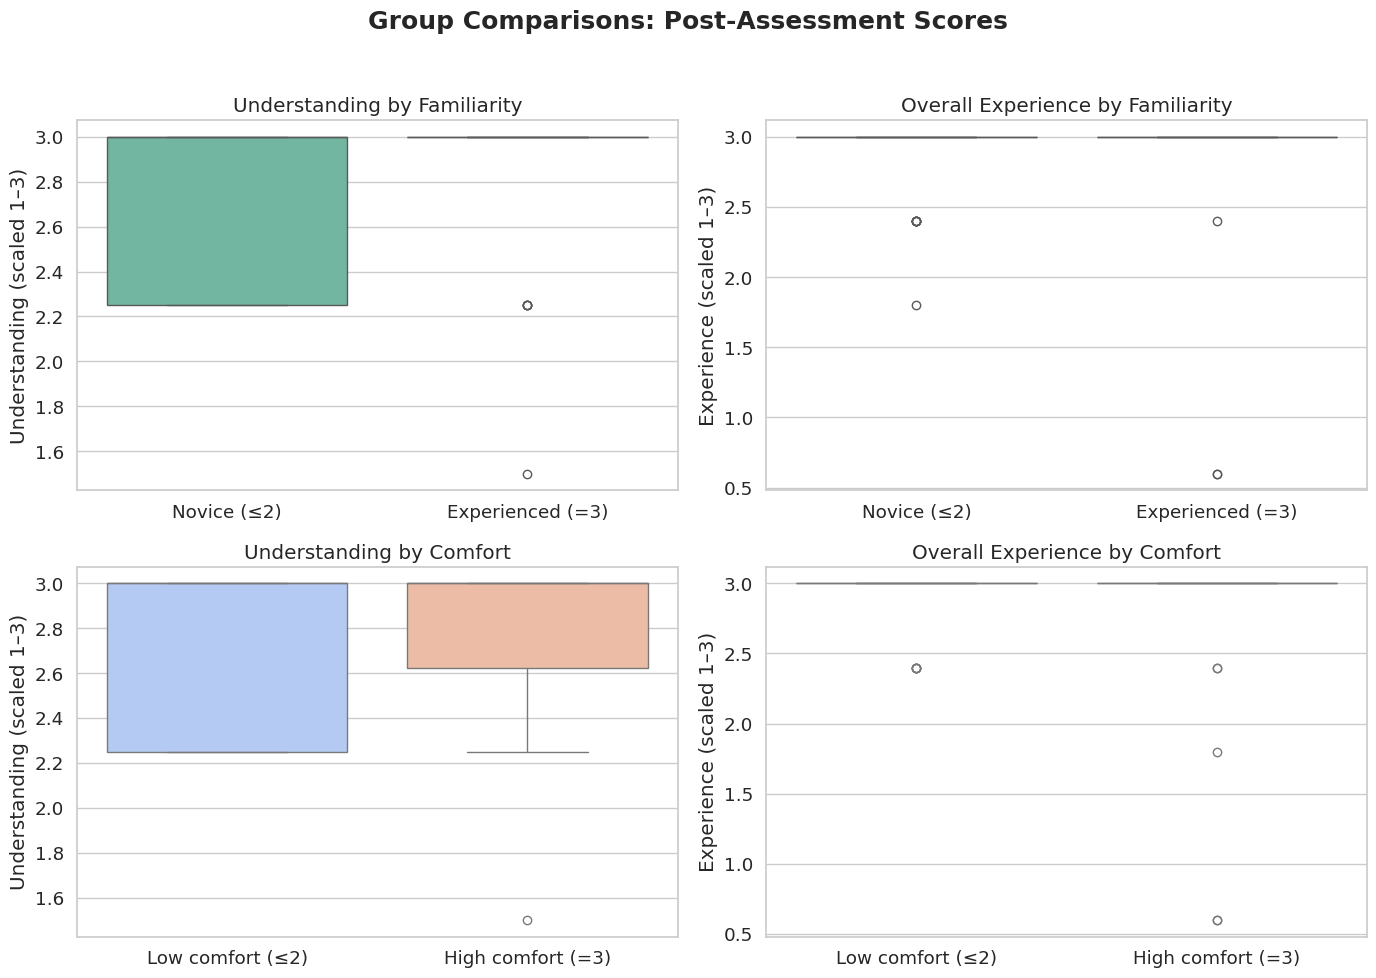

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for publication
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Group Comparisons: Post-Assessment Scores", fontsize=18, weight="bold")

# --- 1. Understanding by Familiarity ---
sns.boxplot(
    data=paired_no_email,
    x="fam_group",
    y="understanding_scaled_1_3",
    palette="Set2",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Understanding by Familiarity")
axes[0, 0].set_ylabel("Understanding (scaled 1–3)")
axes[0, 0].set_xlabel("")

# --- 2. Overall Experience by Familiarity ---
sns.boxplot(
    data=paired_no_email,
    x="fam_group",
    y="experience_scaled_1_3",
    palette="Set2",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Overall Experience by Familiarity")
axes[0, 1].set_ylabel("Experience (scaled 1–3)")
axes[0, 1].set_xlabel("")

# --- 3. Understanding by Comfort ---
sns.boxplot(
    data=paired_no_email,
    x="comfort_group",
    y="understanding_scaled_1_3",
    palette="coolwarm",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Understanding by Comfort")
axes[1, 0].set_ylabel("Understanding (scaled 1–3)")
axes[1, 0].set_xlabel("")

# --- 4. Overall Experience by Comfort ---
sns.boxplot(
    data=paired_no_email,
    x="comfort_group",
    y="experience_scaled_1_3",
    palette="coolwarm",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Overall Experience by Comfort")
axes[1, 1].set_ylabel("Experience (scaled 1–3)")
axes[1, 1].set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipython-input-4228806898.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=paired_no_email, x="fam_group", y="understanding_scaled_1_3", palette="Set2", ax=axes[0, 0])
/tmp/ipython-input-4228806898.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=paired_no_email, x="fam_group", y="experience_scaled_1_3", palette="Set2", ax=axes[0, 1])
/tmp/ipython-input-4228806898.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=paired_no_email, x="comfort_group", y="understanding_scaled_1_3", palette="coolwarm", ax=axes[1, 0])

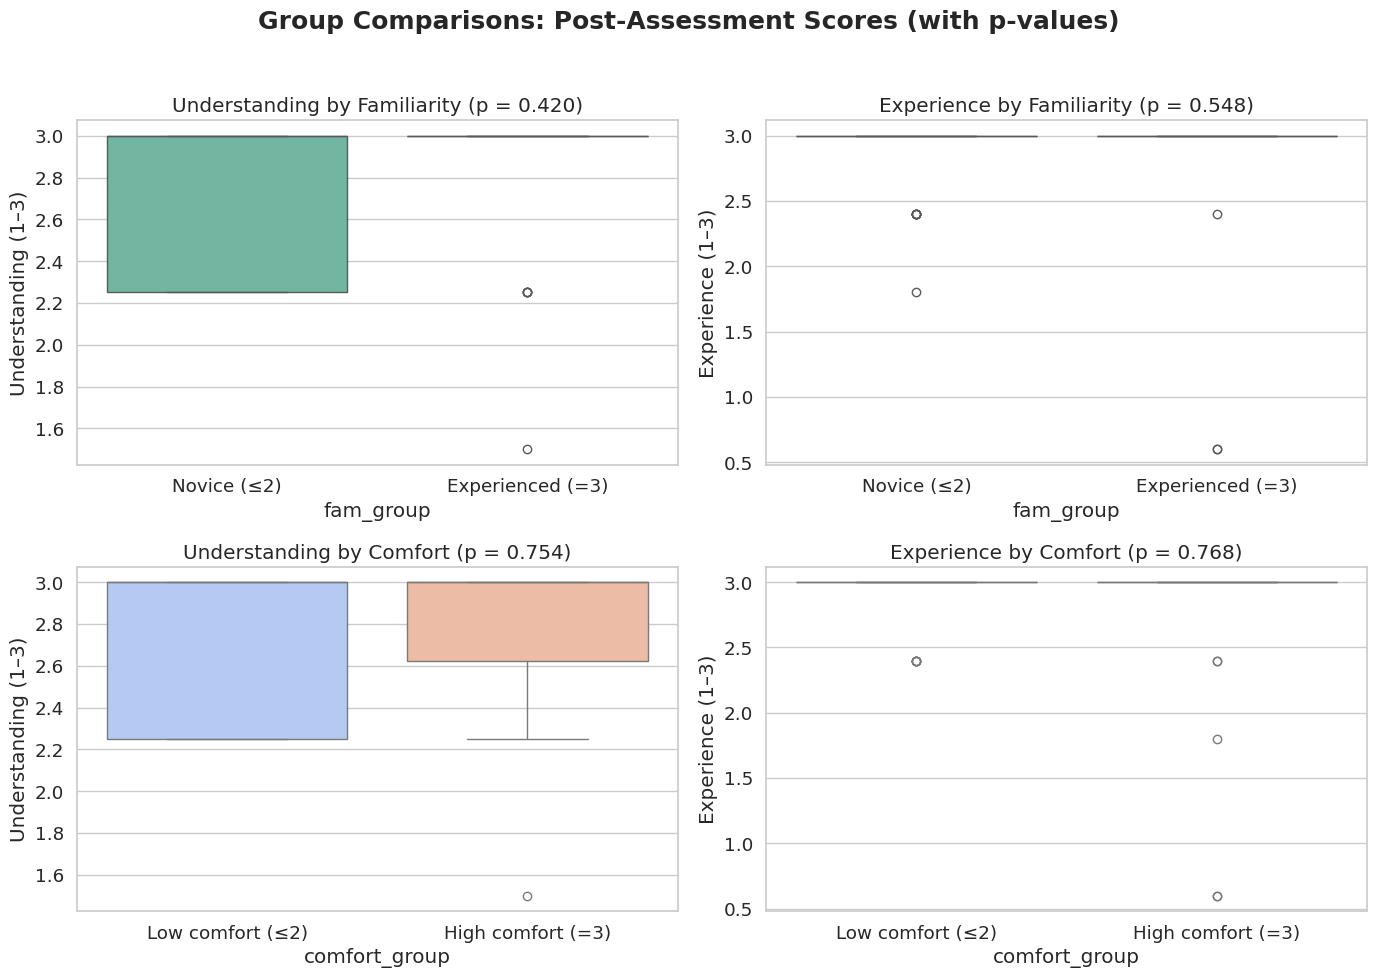

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# Mann–Whitney results you already calculated
pvals = {
    "Understanding by Familiarity": 0.4202,
    "Experience by Familiarity": 0.5485,
    "Understanding by Comfort": 0.7541,
    "Experience by Comfort": 0.7677
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Group Comparisons: Post-Assessment Scores (with p-values)", fontsize=18, weight="bold")

# 1. Understanding by Familiarity
sns.boxplot(data=paired_no_email, x="fam_group", y="understanding_scaled_1_3", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title(f"Understanding by Familiarity (p = {pvals['Understanding by Familiarity']:.3f})")
axes[0, 0].set_ylabel("Understanding (1–3)")

# 2. Experience by Familiarity
sns.boxplot(data=paired_no_email, x="fam_group", y="experience_scaled_1_3", palette="Set2", ax=axes[0, 1])
axes[0, 1].set_title(f"Experience by Familiarity (p = {pvals['Experience by Familiarity']:.3f})")
axes[0, 1].set_ylabel("Experience (1–3)")

# 3. Understanding by Comfort
sns.boxplot(data=paired_no_email, x="comfort_group", y="understanding_scaled_1_3", palette="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title(f"Understanding by Comfort (p = {pvals['Understanding by Comfort']:.3f})")
axes[1, 0].set_ylabel("Understanding (1–3)")

# 4. Experience by Comfort
sns.boxplot(data=paired_no_email, x="comfort_group", y="experience_scaled_1_3", palette="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title(f"Experience by Comfort (p = {pvals['Experience by Comfort']:.3f})")
axes[1, 1].set_ylabel("Experience (1–3)")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [35]:
!pip install cliffs_delta
from cliffs_delta import cliffs_delta


In [36]:
# --- Familiarity groups ---
novice_under = paired[paired["fam_group"] == "Novice (≤2)"]["understanding_scaled_1_3"]
exp_under    = paired[paired["fam_group"] == "Experienced (=3)"]["understanding_scaled_1_3"]

novice_exp   = paired[paired["fam_group"] == "Novice (≤2)"]["experience_scaled_1_3"]
exp_exp      = paired[paired["fam_group"] == "Experienced (=3)"]["experience_scaled_1_3"]

# --- Comfort groups ---
low_under    = paired[paired["comfort_group"] == "Low comfort (≤2)"]["understanding_scaled_1_3"]
high_under   = paired[paired["comfort_group"] == "High comfort (=3)"]["understanding_scaled_1_3"]

low_exp      = paired[paired["comfort_group"] == "Low comfort (≤2)"]["experience_scaled_1_3"]
high_exp     = paired[paired["comfort_group"] == "High comfort (=3)"]["experience_scaled_1_3"]

# ---- Calculate Cliff’s delta for all four ----
print("📊 Cliff's delta – Understanding by Familiarity:", cliffs_delta(novice_under, exp_under))
print("📊 Cliff's delta – Experience by Familiarity:", cliffs_delta(novice_exp, exp_exp))

print("📊 Cliff's delta – Understanding by Comfort:", cliffs_delta(low_under, high_under))
print("📊 Cliff's delta – Experience by Comfort:", cliffs_delta(low_exp, high_exp))


📊 Cliff's delta – Understanding by Familiarity: (-0.10144927536231885, 'negligible')
📊 Cliff's delta – Experience by Familiarity: (-0.06455862977602109, 'negligible')
📊 Cliff's delta – Understanding by Comfort: (-0.03959131545338442, 'negligible')
📊 Cliff's delta – Experience by Comfort: (0.031928480204342274, 'negligible')


/tmp/ipython-input-564526827.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_e, x="Group", y="Score", ax=ax, palette="pastel")
/tmp/ipython-input-564526827.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_f, x="Group", y="Score", ax=ax, palette="pastel")


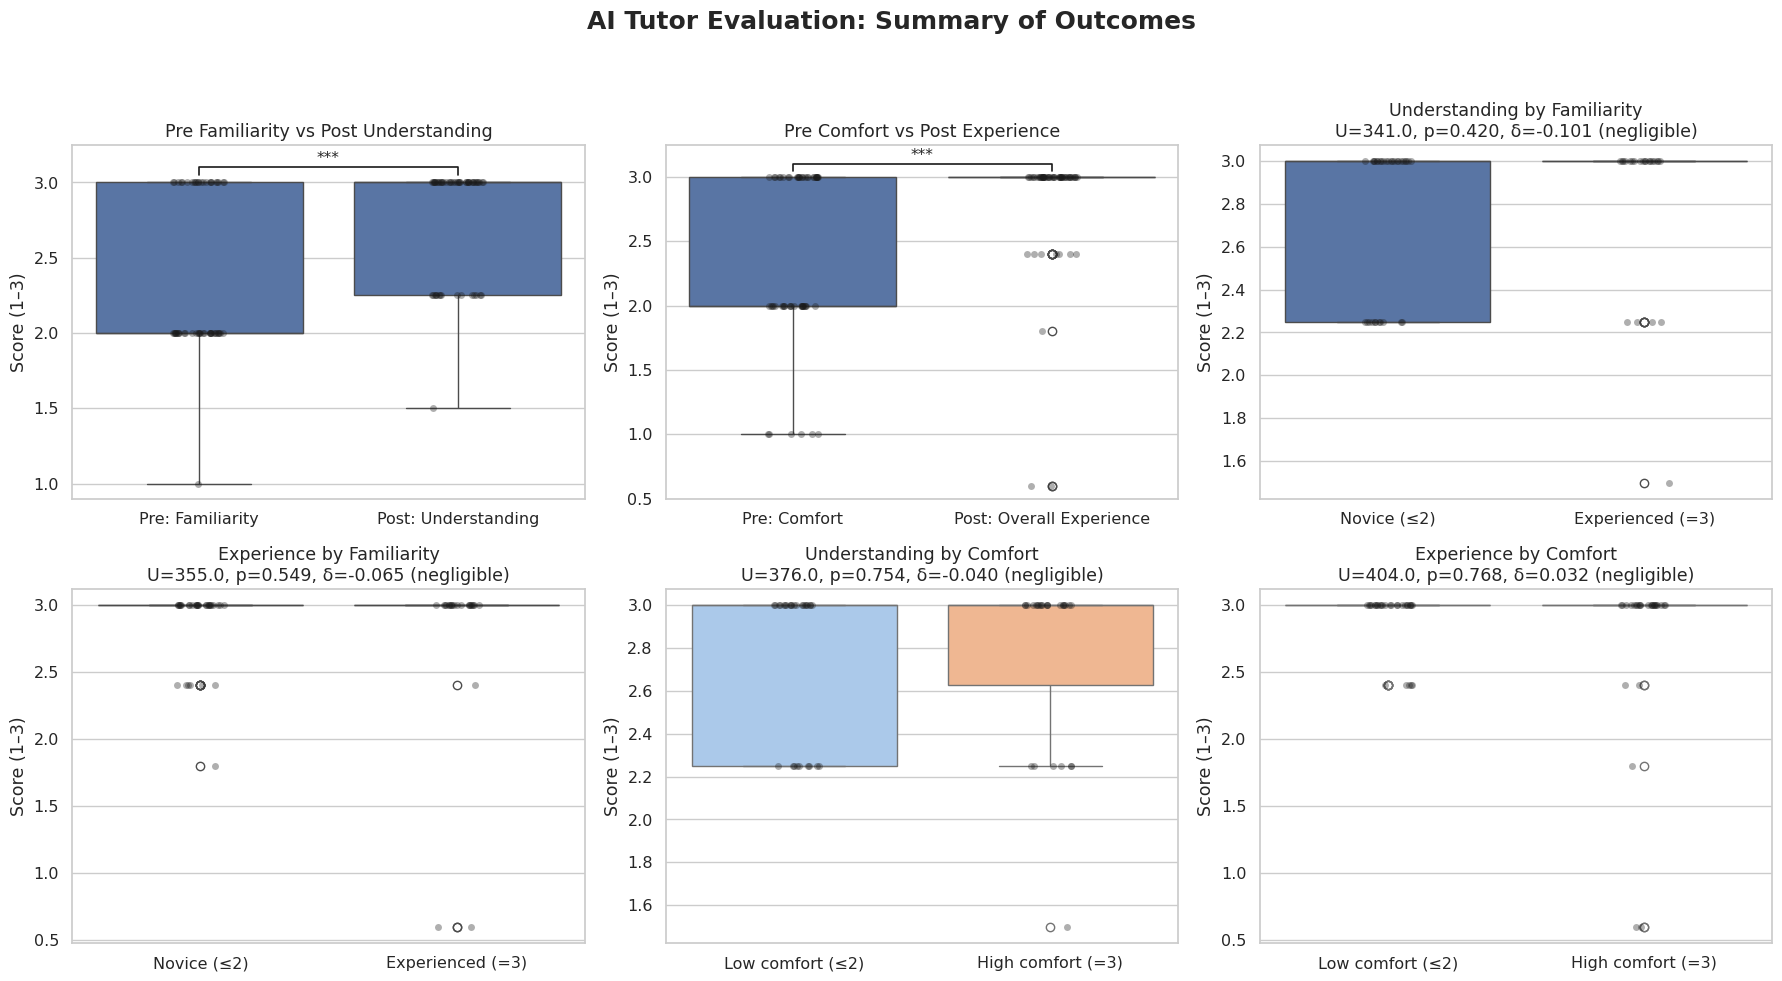

Wilcoxon pre→post:
Familiarity vs Understanding: W=88, p=0.00003
Comfort vs Experience:        W=102, p=0.00061

Mann–Whitney + Cliff's delta (groups):
Underst. by Familiarity: U=341, p=0.420, delta=-0.101 (negligible)
Exper.   by Familiarity: U=355, p=0.549, delta=-0.065 (negligible)
Underst. by Comfort:     U=376, p=0.754, delta=-0.040 (negligible)
Exper.   by Comfort:     U=404, p=0.768, delta=0.032 (negligible)


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, mannwhitneyu

# ----- helpers -----
def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    # all pairwise comparisons
    greater = 0; less = 0
    for x in a:
        greater += np.sum(x > b)
        less    += np.sum(x < b)
    n = len(a)*len(b)
    delta = (greater - less) / n if n > 0 else 0.0
    ad = abs(delta)
    if   ad < 0.147: size = "negligible"
    elif ad < 0.33:  size = "small"
    elif ad < 0.474: size = "medium"
    else:            size = "large"
    return delta, size

def add_sigbar(ax, x1, x2, y, p, h=0.05):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c="k")
    if p < 0.001: s = "***"
    elif p < 0.01: s = "**"
    elif p < 0.05: s = "*"
    else: s = f"p={p:.3f}"
    ax.text((x1+x2)/2, y+h*1.2, s, ha="center", va="bottom", fontsize=11)

sns.set(style="whitegrid", font_scale=1.05)

# ----- build vectors from paired_no_email -----
# pre vs post
pre_fam = paired_no_email["familiarity_num"].to_numpy()
post_under_1_3 = paired_no_email["understanding_scaled_1_3"].to_numpy()

pre_comf = paired_no_email["comfort_num"].to_numpy()
post_exp_1_3 = paired_no_email["experience_scaled_1_3"].to_numpy()

# Wilcoxon tests (paired)
w1 = wilcoxon(pre_fam, post_under_1_3/1.0)  # both on 1–3 scale
w2 = wilcoxon(pre_comf, post_exp_1_3/1.0)   # both on 1–3 scale

# group splits
g_fam_n = paired_no_email["fam_group"] == "Novice (≤2)"
g_fam_e = paired_no_email["fam_group"] == "Experienced (=3)"
g_comf_l = paired_no_email["comfort_group"] == "Low comfort (≤2)"
g_comf_h = paired_no_email["comfort_group"] == "High comfort (=3)"

under_by_fam = [paired_no_email.loc[g_fam_n, "understanding_scaled_1_3"],
                paired_no_email.loc[g_fam_e, "understanding_scaled_1_3"]]
exp_by_fam   = [paired_no_email.loc[g_fam_n, "experience_scaled_1_3"],
                paired_no_email.loc[g_fam_e, "experience_scaled_1_3"]]

under_by_comf = [paired_no_email.loc[g_comf_l, "understanding_scaled_1_3"],
                 paired_no_email.loc[g_comf_h, "understanding_scaled_1_3"]]
exp_by_comf   = [paired_no_email.loc[g_comf_l, "experience_scaled_1_3"],
                 paired_no_email.loc[g_comf_h, "experience_scaled_1_3"]]

# Mann–Whitney and Cliff's delta
u1 = mannwhitneyu(under_by_fam[0], under_by_fam[1], alternative="two-sided")
u2 = mannwhitneyu(exp_by_fam[0],   exp_by_fam[1],   alternative="two-sided")
u3 = mannwhitneyu(under_by_comf[0],under_by_comf[1],alternative="two-sided")
u4 = mannwhitneyu(exp_by_comf[0],  exp_by_comf[1],  alternative="two-sided")

d1 = cliffs_delta(under_by_fam[0], under_by_fam[1])
d2 = cliffs_delta(exp_by_fam[0],   exp_by_fam[1])
d3 = cliffs_delta(under_by_comf[0],under_by_comf[1])
d4 = cliffs_delta(exp_by_comf[0],  exp_by_comf[1])

# ----- figure -----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("AI Tutor Evaluation: Summary of Outcomes", fontsize=18, weight="bold")

# A. Pre vs Post: Familiarity -> Understanding (boxplot)
ax = axes[0,0]
df_a = pd.DataFrame({
    "Measure": ["Pre: Familiarity"]*len(pre_fam) + ["Post: Understanding"]*len(post_under_1_3),
    "Score":   np.concatenate([pre_fam, post_under_1_3])
})
sns.boxplot(data=df_a, x="Measure", y="Score", ax=ax)
sns.stripplot(data=df_a, x="Measure", y="Score", color="k", alpha=0.35, jitter=True, ax=ax)
ax.set_title("Pre Familiarity vs Post Understanding")
ax.set_ylabel("Score (1–3)")
ax.set_xlabel("")
ymax = df_a["Score"].max()
add_sigbar(ax, 0, 1, ymax+0.05, w1.pvalue, h=0.05)
ax.set_ylim(df_a["Score"].min()-0.1, ymax+0.25)

# B. Pre vs Post: Comfort -> Experience (boxplot)
ax = axes[0,1]
df_b = pd.DataFrame({
    "Measure": ["Pre: Comfort"]*len(pre_comf) + ["Post: Overall Experience"]*len(post_exp_1_3),
    "Score":   np.concatenate([pre_comf, post_exp_1_3])
})
sns.boxplot(data=df_b, x="Measure", y="Score", ax=ax)
sns.stripplot(data=df_b, x="Measure", y="Score", color="k", alpha=0.35, jitter=True, ax=ax)
ax.set_title("Pre Comfort vs Post Experience")
ax.set_ylabel("Score (1–3)")
ax.set_xlabel("")
ymax = df_b["Score"].max()
add_sigbar(ax, 0, 1, ymax+0.05, w2.pvalue, h=0.05)
ax.set_ylim(df_b["Score"].min()-0.1, ymax+0.25)

# C. Understanding by Familiarity (boxplot with p and delta)
ax = axes[0,2]
df_c = paired_no_email[["fam_group","understanding_scaled_1_3"]].rename(
    columns={"fam_group":"Group","understanding_scaled_1_3":"Score"})
sns.boxplot(data=df_c, x="Group", y="Score", ax=ax)
sns.stripplot(data=df_c, x="Group", y="Score", color="k", alpha=0.35, jitter=True, ax=ax)
ax.set_title(f"Understanding by Familiarity\nU={u1.statistic:.1f}, p={u1.pvalue:.3f}, δ={d1[0]:.3f} ({d1[1]})")
ax.set_ylabel("Score (1–3)"); ax.set_xlabel("")

# D. Experience by Familiarity
ax = axes[1,0]
df_d = paired_no_email[["fam_group","experience_scaled_1_3"]].rename(
    columns={"fam_group":"Group","experience_scaled_1_3":"Score"})
sns.boxplot(data=df_d, x="Group", y="Score", ax=ax)
sns.stripplot(data=df_d, x="Group", y="Score", color="k", alpha=0.35, jitter=True, ax=ax)
ax.set_title(f"Experience by Familiarity\nU={u2.statistic:.1f}, p={u2.pvalue:.3f}, δ={d2[0]:.3f} ({d2[1]})")
ax.set_ylabel("Score (1–3)"); ax.set_xlabel("")

# E. Understanding by Comfort
ax = axes[1,1]
df_e = paired_no_email[["comfort_group","understanding_scaled_1_3"]].rename(
    columns={"comfort_group":"Group","understanding_scaled_1_3":"Score"})
sns.boxplot(data=df_e, x="Group", y="Score", ax=ax, palette="pastel")
sns.stripplot(data=df_e, x="Group", y="Score", color="k", alpha=0.35, jitter=True, ax=ax)
ax.set_title(f"Understanding by Comfort\nU={u3.statistic:.1f}, p={u3.pvalue:.3f}, δ={d3[0]:.3f} ({d3[1]})")
ax.set_ylabel("Score (1–3)"); ax.set_xlabel("")

# F. Experience by Comfort
ax = axes[1,2]
df_f = paired_no_email[["comfort_group","experience_scaled_1_3"]].rename(
    columns={"comfort_group":"Group","experience_scaled_1_3":"Score"})
sns.boxplot(data=df_f, x="Group", y="Score", ax=ax, palette="pastel")
sns.stripplot(data=df_f, x="Group", y="Score", color="k", alpha=0.35, jitter=True, ax=ax)
ax.set_title(f"Experience by Comfort\nU={u4.statistic:.1f}, p={u4.pvalue:.3f}, δ={d4[0]:.3f} ({d4[1]})")
ax.set_ylabel("Score (1–3)"); ax.set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Wilcoxon pre→post:")
print(f"Familiarity vs Understanding: W={w1.statistic:.0f}, p={w1.pvalue:.5f}")
print(f"Comfort vs Experience:        W={w2.statistic:.0f}, p={w2.pvalue:.5f}")

print("\nMann–Whitney + Cliff's delta (groups):")
print(f"Underst. by Familiarity: U={u1.statistic:.0f}, p={u1.pvalue:.3f}, delta={d1[0]:.3f} ({d1[1]})")
print(f"Exper.   by Familiarity: U={u2.statistic:.0f}, p={u2.pvalue:.3f}, delta={d2[0]:.3f} ({d2[1]})")
print(f"Underst. by Comfort:     U={u3.statistic:.0f}, p={u3.pvalue:.3f}, delta={d3[0]:.3f} ({d3[1]})")
print(f"Exper.   by Comfort:     U={u4.statistic:.0f}, p={u4.pvalue:.3f}, delta={d4[0]:.3f} ({d4[1]})")


In [38]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, mannwhitneyu

# --- vectors from your cleaned frame ---
N_total  = 57                     # total participants
N_paired = len(paired_no_email)   # should be 56

pre_fam   = paired_no_email["familiarity_num"].to_numpy()
post_under= paired_no_email["understanding_scaled_1_3"].to_numpy()

pre_comf  = paired_no_email["comfort_num"].to_numpy()
post_exp  = paired_no_email["experience_scaled_1_3"].to_numpy()

# Wilcoxon (paired)
w1 = wilcoxon(pre_fam, post_under)
w2 = wilcoxon(pre_comf, post_exp)

# Groups
g_fam_n = paired_no_email["fam_group"] == "Novice (≤2)"
g_fam_e = paired_no_email["fam_group"] == "Experienced (=3)"
g_com_l = paired_no_email["comfort_group"] == "Low comfort (≤2)"
g_com_h = paired_no_email["comfort_group"] == "High comfort (=3)"

u1 = mannwhitneyu(paired_no_email.loc[g_fam_n,"understanding_scaled_1_3"],
                  paired_no_email.loc[g_fam_e,"understanding_scaled_1_3"], alternative="two-sided")
u2 = mannwhitneyu(paired_no_email.loc[g_fam_n,"experience_scaled_1_3"],
                  paired_no_email.loc[g_fam_e,"experience_scaled_1_3"],   alternative="two-sided")
u3 = mannwhitneyu(paired_no_email.loc[g_com_l,"understanding_scaled_1_3"],
                  paired_no_email.loc[g_com_h,"understanding_scaled_1_3"], alternative="two-sided")
u4 = mannwhitneyu(paired_no_email.loc[g_com_l,"experience_scaled_1_3"],
                  paired_no_email.loc[g_com_h,"experience_scaled_1_3"],   alternative="two-sided")

# Cliff's delta helper (inline, no extra install)
def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    greater = sum((x > b).sum() for x in a)
    less    = sum((x < b).sum() for x in a)
    n = len(a) * len(b)
    d = (greater - less) / n if n else 0.0
    return d

d1 = cliffs_delta(paired_no_email.loc[g_fam_n,"understanding_scaled_1_3"],
                  paired_no_email.loc[g_fam_e,"understanding_scaled_1_3"])
d2 = cliffs_delta(paired_no_email.loc[g_fam_n,"experience_scaled_1_3"],
                  paired_no_email.loc[g_fam_e,"experience_scaled_1_3"])
d3 = cliffs_delta(paired_no_email.loc[g_com_l,"understanding_scaled_1_3"],
                  paired_no_email.loc[g_com_h,"understanding_scaled_1_3"])
d4 = cliffs_delta(paired_no_email.loc[g_com_l,"experience_scaled_1_3"],
                  paired_no_email.loc[g_com_h,"experience_scaled_1_3"])

def eff_label(d):
    ad = abs(d)
    if ad < 0.147: return "negligible"
    if ad < 0.33:  return "small"
    if ad < 0.474: return "medium"
    return "large"

tbl = pd.DataFrame([
    ["Pre→Post", "Familiarity → Understanding", N_paired,
     np.mean(pre_fam), np.mean(post_under), "Wilcoxon", w1.statistic, w1.pvalue, np.nan, ""],
    ["Pre→Post", "Comfort → Experience",       N_paired,
     np.mean(pre_comf), np.mean(post_exp),   "Wilcoxon", w2.statistic, w2.pvalue, np.nan, ""],
    ["Groups", "Understanding by Familiarity", N_paired,
     np.nan, np.nan, "Mann–Whitney U", u1.statistic, u1.pvalue, d1, eff_label(d1)],
    ["Groups", "Experience by Familiarity",    N_paired,
     np.nan, np.nan, "Mann–Whitney U", u2.statistic, u2.pvalue, d2, eff_label(d2)],
    ["Groups", "Understanding by Comfort",     N_paired,
     np.nan, np.nan, "Mann–Whitney U", u3.statistic, u3.pvalue, d3, eff_label(d3)],
    ["Groups", "Experience by Comfort",        N_paired,
     np.nan, np.nan, "Mann–Whitney U", u4.statistic, u4.pvalue, d4, eff_label(d4)]
], columns=["Level","Measure","N","Mean (Pre)","Mean (Post)","Test","Statistic","p-value","Cliff δ","Effect"])

# Round nicely and save
tbl_rounded = tbl.copy()
tbl_rounded["Mean (Pre)"]  = tbl_rounded["Mean (Pre)"].round(2)
tbl_rounded["Mean (Post)"] = tbl_rounded["Mean (Post)"].round(2)
tbl_rounded["Statistic"]   = tbl_rounded["Statistic"].round(2)
tbl_rounded["p-value"]     = tbl_rounded["p-value"].map(lambda p: f"{p:.5f}" if pd.notna(p) else "")
tbl_rounded["Cliff δ"]     = tbl_rounded["Cliff δ"].map(lambda d: f"{d:.3f}" if pd.notna(d) else "")

display(tbl_rounded)
tbl_rounded.to_csv("/content/results_summary_table.csv", index=False)
print("Saved /content/results_summary_table.csv")

# (Optional) LaTeX for the paper
print(tbl_rounded.to_latex(index=False, escape=True))


,Level,Measure,N,Mean (Pre),Mean (Post),Test,Statistic,p-value,Cliff δ,Effect
0,Pre→Post,Familiarity → Understanding,56,2.39,2.77,Wilcoxon,88.0,0.00003,,
1,Pre→Post,Comfort → Experience,56,2.38,2.82,Wilcoxon,102.0,0.00061,,
2,Groups,Understanding by Familiarity,56,NaN,NaN,Mann–Whitney U,341.0,0.42024,-0.101,negligible
3,Groups,Experience by Familiarity,56,NaN,NaN,Mann–Whitney U,355.0,0.54854,-0.065,negligible
4,Groups,Understanding by Comfort,56,NaN,NaN,Mann–Whitney U,376.0,0.75410,-0.040,negligible
5,Groups,Experience by Comfort,56,NaN,NaN,Mann–Whitney U,404.0,0.76774,0.032,negligible


Saved /content/results_summary_table.csv
\begin{tabular}{llrrrlrlll}
\toprule
Level & Measure & N & Mean (Pre) & Mean (Post) & Test & Statistic & p-value & Cliff δ & Effect \\
\midrule
Pre→Post & Familiarity → Understanding & 56 & 2.390000 & 2.770000 & Wilcoxon & 88.000000 & 0.00003 &  &  \\
Pre→Post & Comfort → Experience & 56 & 2.380000 & 2.820000 & Wilcoxon & 102.000000 & 0.00061 &  &  \\
Groups & Understanding by Familiarity & 56 & NaN & NaN & Mann–Whitney U & 341.000000 & 0.42024 & -0.101 & negligible \\
Groups & Experience by Familiarity & 56 & NaN & NaN & Mann–Whitney U & 355.000000 & 0.54854 & -0.065 & negligible \\
Groups & Understanding by Comfort & 56 & NaN & NaN & Mann–Whitney U & 376.000000 & 0.75410 & -0.040 & negligible \\
Groups & Experience by Comfort & 56 & NaN & NaN & Mann–Whitney U & 404.000000 & 0.76774 & 0.032 & negligible \\
\bottomrule
\end{tabular}



In [39]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# ---------- rank-biserial for paired (Wilcoxon) ----------
def wilcoxon_rank_biserial(pre, post, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    d = np.asarray(post) - np.asarray(pre)
    # remove zeros (Wilcoxon ignores ties at 0)
    mask = d != 0
    d = d[mask]
    if len(d) == 0:
        return np.nan, (np.nan, np.nan)

    ranks = rankdata(np.abs(d), method="average")
    sum_pos = ranks[d > 0].sum()
    sum_neg = ranks[d < 0].sum()
    denom = len(d) * (len(d) + 1) / 2.0
    r_rb = (sum_pos - sum_neg) / denom  # in [-1, 1]

    # bootstrap CI
    boot = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(d), len(d))
        bd = d[idx]
        if np.all(bd == 0):
            continue
        branks = rankdata(np.abs(bd), method="average")
        bsum_pos = branks[bd > 0].sum()
        bsum_neg = branks[bd < 0].sum()
        boot.append((bsum_pos - bsum_neg) / (len(bd) * (len(bd) + 1) / 2.0))
    if len(boot) == 0:
        ci = (np.nan, np.nan)
    else:
        lo, hi = np.percentile(boot, [2.5, 97.5])
        ci = (lo, hi)
    return r_rb, ci

# ----- compute effect sizes for your two Wilcoxon rows -----
r1, ci1 = wilcoxon_rank_biserial(pre_fam, post_under)  # Familiarity → Understanding
r2, ci2 = wilcoxon_rank_biserial(pre_comf, post_exp)   # Comfort → Experience

def fmt_ci(ci):
    return f"[{ci[0]:.2f}, {ci[1]:.2f}]" if np.all(np.isfinite(ci)) else ""

# Load the CSV we just wrote (or re-use tbl_rounded from the prior cell)
tbl = pd.read_csv("/content/results_summary_table.csv")

# Add r_rb to Wilcoxon rows (rows 0 and 1 in your table)
tbl.loc[0, "Wilcoxon r_rb"] = round(r1, 3)
tbl.loc[0, "r_rb 95% CI"]   = fmt_ci(ci1)
tbl.loc[1, "Wilcoxon r_rb"] = round(r2, 3)
tbl.loc[1, "r_rb 95% CI"]   = fmt_ci(ci2)

# Clean formatting
for col in ["Mean (Pre)","Mean (Post)","Statistic","p-value","Cliff δ"]:
    if col in tbl.columns:
        pass
tbl["p-value"] = tbl["p-value"].apply(lambda x: f"{float(x):.5f}" if str(x) not in ["", "nan"] else "")

display(tbl)
tbl.to_csv("/content/results_summary_table_with_r.csv", index=False)
print("Saved /content/results_summary_table_with_r.csv")

# ----- LaTeX with bolding for significant p-values (< .05) -----
def bold_sig(val):
    try:
        p = float(val)
        return f"\\textbf{{{p:.5f}}}" if p < 0.05 else f"{p:.5f}"
    except:
        return val

latex_tbl = tbl.copy()
latex_tbl["p-value"] = latex_tbl["p-value"].map(bold_sig)

latex = latex_tbl.to_latex(index=False, escape=True,
                           column_format="llrrrlrllll",
                           caption=("Summary of statistical analyses. "
                                    "Wilcoxon rows report matched rank–biserial effect size "
                                    "$r_{rb}$ with 95\\% CI. "
                                    "Cliff’s $\\delta$ shown for between-group tests."),
                           label="tab:results_summary")

print(latex)
s

,Level,Measure,N,Mean (Pre),Mean (Post),Test,Statistic,p-value,Cliff δ,Effect,Wilcoxon r_rb,r_rb 95% CI
0,Pre→Post,Familiarity → Understanding,56,2.39,2.77,Wilcoxon,88.0,0.00003,NaN,NaN,0.762,"[0.50, 0.96]"
1,Pre→Post,Comfort → Experience,56,2.38,2.82,Wilcoxon,102.0,0.00061,NaN,NaN,0.657,"[0.31, 0.96]"
2,Groups,Understanding by Familiarity,56,NaN,NaN,Mann–Whitney U,341.0,0.42024,-0.101,negligible,NaN,NaN
3,Groups,Experience by Familiarity,56,NaN,NaN,Mann–Whitney U,355.0,0.54854,-0.065,negligible,NaN,NaN
4,Groups,Understanding by Comfort,56,NaN,NaN,Mann–Whitney U,376.0,0.75410,-0.040,negligible,NaN,NaN
5,Groups,Experience by Comfort,56,NaN,NaN,Mann–Whitney U,404.0,0.76774,0.032,negligible,NaN,NaN


Saved /content/results_summary_table_with_r.csv
\begin{table}
\caption{Summary of statistical analyses. Wilcoxon rows report matched rank–biserial effect size $r_{rb}$ with 95\% CI. Cliff’s $\delta$ shown for between-group tests.}
\label{tab:results_summary}
\begin{tabular}{llrrrlrllll}
\toprule
Level & Measure & N & Mean (Pre) & Mean (Post) & Test & Statistic & p-value & Cliff δ & Effect & Wilcoxon r\_rb & r\_rb 95\% CI \\
\midrule
Pre→Post & Familiarity → Understanding & 56 & 2.390000 & 2.770000 & Wilcoxon & 88.000000 & \textbackslash textbf\{0.00003\} & NaN & NaN & 0.762000 & [0.50, 0.96] \\
Pre→Post & Comfort → Experience & 56 & 2.380000 & 2.820000 & Wilcoxon & 102.000000 & \textbackslash textbf\{0.00061\} & NaN & NaN & 0.657000 & [0.31, 0.96] \\
Groups & Understanding by Familiarity & 56 & NaN & NaN & Mann–Whitney U & 341.000000 & 0.42024 & -0.101000 & negligible & NaN & NaN \\
Groups & Experience by Familiarity & 56 & NaN & NaN & Mann–Whitney U & 355.000000 & 0.54854 & -0.065000 